In [ ]:
%%bash
pip install pandas numpy scikit-learn scipy statsmodels matplotlib seaborn \
            rdkit bioservices pubchempy gseapy requests rpy2 --quiet
echo "=== python + chemistry stack installed ==="
apt-get install -y r-base-core > /dev/null 2>&1
R -e 'if(!requireNamespace("BiocManager",quietly=TRUE)) install.packages("BiocManager",repos="http://cran.r-project.org")' > /dev/null 2>&1
R -e 'BiocManager::install(c("pathview","limma"), update=FALSE, ask=FALSE)' > /dev/null 2>&1
echo "=== R + pathview + limma installed ==="

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.8/277.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.5/718.5 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.6/270

In [ ]:
%load_ext rpy2.ipython
print("R bridge loaded.")

R bridge loaded.


In [ ]:
import requests, pandas as pd, numpy as np, os, re, io
os.makedirs("data", exist_ok=True)

ACC   = "MTBLS12968"   # "PCOS preterm plasma metabolome"
MAF   = "m_MTBLS12968_LC-MS_alternating_reverse-phase_metabolite_profiling_v2_maf.tsv"
SHEET = "s_MTBLS12968.txt"
BASE  = f"https://ftp.ebi.ac.uk/pub/databases/metabolights/studies/public/{ACC}/"

def fetch(fname):
    r = requests.get(BASE + fname, timeout=180)
    r.raise_for_status()
    return r.text

print("Downloading real MetaboLights data:", ACC)
maf_text   = fetch(MAF)
sheet_text = fetch(SHEET)
open(f"data/{MAF}", "w").write(maf_text)
open(f"data/{SHEET}", "w").write(sheet_text)

# HARD STOP if the real data did not download — never proceed on fake data.
assert len(maf_text) > 1000, "MAF file too small — download failed. This pipeline uses real data only."
print(f"MAF downloaded: {len(maf_text):,} bytes")
print(f"Sample sheet downloaded: {len(sheet_text):,} bytes")

MAF downloaded: 266,311 bytes
Sample sheet downloaded: 43,712 bytes


In [ ]:
# --- parse the metabolite matrix ---
maf = pd.read_csv(io.StringIO(maf_text), sep="\t")

anno_like = ["database_identifier","metabolite_identification","chemical_formula","smiles","inchi",
             "mass_to_charge","retention_time","fragmentation","modifications","charge","taxid",
             "species","database","reliability","uri","search_engine","search_engine_score",
             "metabolite_assignment_file"]
anno = [c for c in maf.columns if c.lower() in [a.lower() for a in anno_like]]
name_col = "metabolite_identification" if "metabolite_identification" in maf.columns else maf.columns[1]
sample_cols = [c for c in maf.columns if c not in anno]

data = maf.set_index(name_col)[sample_cols]
data = data[~data.index.isna()]
data.index = data.index.astype(str)
data = data[data.index.str.strip() != ""]
data = data.apply(pd.to_numeric, errors="coerce").dropna(how="all")
print("Metabolite matrix:", data.shape, "(metabolites x samples)")

# --- read the sample sheet and map each sample to PCOS vs control ---
sheet = pd.read_csv(io.StringIO(sheet_text), sep="\t")
name_c = next((c for c in sheet.columns if "Sample Name" in c), sheet.columns[0])
factor_cols = [c for c in sheet.columns if "Factor Value" in c or "Characteristics" in c]

# inspect the factor columns once (prints the group vocabulary of this study)
for fc in factor_cols:
    print(f"  {fc}: {list(pd.Series(sheet[fc]).dropna().unique())[:6]}")

# build sample -> group using PCOS/case keywords across all factor columns
def group_of(row):
    txt = " ".join(str(row.get(c, "")) for c in factor_cols).lower()
    return "PCOS" if re.search(r"pcos|polycystic|case|patient|hyperandrogen", txt) else "control"

sample_group = {str(r[name_c]): group_of(r) for _, r in sheet.iterrows()}
labels = np.array([sample_group.get(c, "control") for c in data.columns])
print("\nGroups:", pd.Series(labels).value_counts().to_dict())

# If the sheet uses different sample-column names than the MAF, or gives one group only,
# open data/s_MTBLS12968.txt, find the Factor Value column naming PCOS vs control,
# and set `labels` from it explicitly (normal metabolomics curation).
assert len(set(labels)) == 2, ("Could not resolve two groups automatically. "
    "Open data/s_MTBLS12968.txt and map the PCOS/control factor column explicitly.")

Metabolite matrix: (185, 153) (metabolites x samples)
  Characteristics[Organism]: ['Homo sapiens']
  Characteristics[Organism part]: ['blood plasma']
  Characteristics[Variant]: []
  Characteristics[Sample type]: ['blood plasma']
  Factor Value[Group]: ['HP-P1', 'HP-P2', 'HP-P3', 'HP-P4', 'HP-P5', 'HP-P6']

Groups: {'control': 87, 'PCOS': 66}


In [ ]:
data = data.apply(lambda r: r.fillna(r.min()/2), axis=1)      # half-min imputation
logdata = np.log2(data + 1)
pareto = logdata.sub(logdata.mean(axis=1), axis=0).div(np.sqrt(logdata.std(axis=1)), axis=0)
print("Preprocessed:", pareto.shape)

Preprocessed: (185, 153)


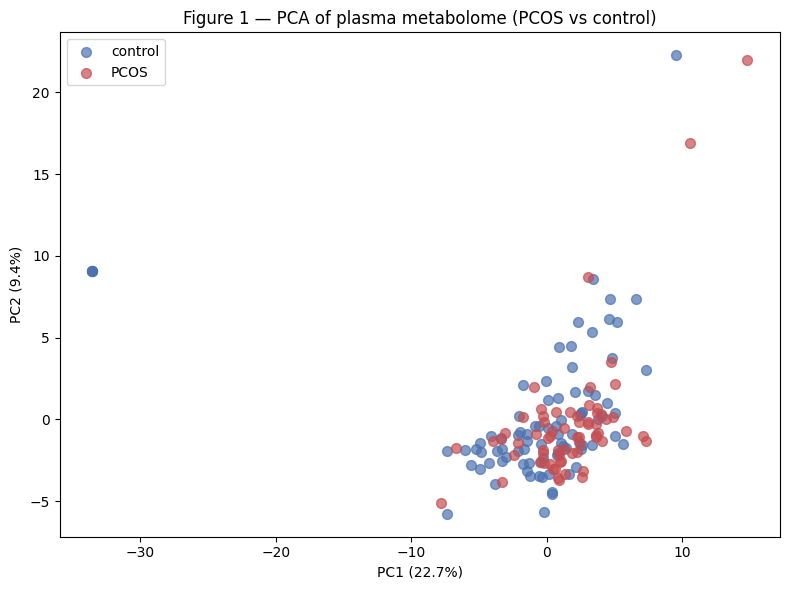

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(pareto.T.values)
pca = PCA(n_components=2); pcs = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
for lab, c in [("control", "#4C72B0"), ("PCOS", "#C44E52")]:
    m = labels == lab
    plt.scatter(pcs[m, 0], pcs[m, 1], label=lab, s=50, alpha=0.7, c=c)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Figure 1 — PCA of plasma metabolome (PCOS vs control)")
plt.legend(); plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

ctrl = data.columns[labels == "control"]; pcos = data.columns[labels == "PCOS"]
rows = []
for m in data.index:
    t, p = stats.ttest_ind(logdata.loc[m, pcos], logdata.loc[m, ctrl])
    lfc = logdata.loc[m, pcos].mean() - logdata.loc[m, ctrl].mean()
    rows.append((m, lfc, p))
de = pd.DataFrame(rows, columns=["metabolite", "log2FC", "pval"]).dropna()
de["padj"] = multipletests(de["pval"], method="fdr_bh")[1]
de = de.sort_values("padj")
sig = de[(de["padj"] < 0.05) & (de["log2FC"].abs() > 0.5)]
print(f"Significant differential metabolites: {len(sig)}")
print(sig.head(15).to_string(index=False))
de.to_csv("differential_metabolites.csv", index=False)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Significant differential metabolites: 8
                          metabolite   log2FC     pval     padj
         Dihomo-gamma-linolenic acid 0.723417 0.000003 0.000296
7Z,10Z,13Z,16Z-Docosatetraenoic acid 0.519760 0.000002 0.000296
     11Z,14Z,17Z-Eicosatrienoic acid 0.516455 0.000006 0.000343
                    Palmitoleic acid 0.603294 0.000018 0.000684
                  Palmitelaidic acid 1.058660 0.000024 0.000735
              10Z-Heptadecenoic acid 1.015783 0.000106 0.002790
              10E-Heptadecenoic acid 0.804790 0.000819 0.011122
                Gamma-Linolenic acid 0.547922 0.002356 0.024094


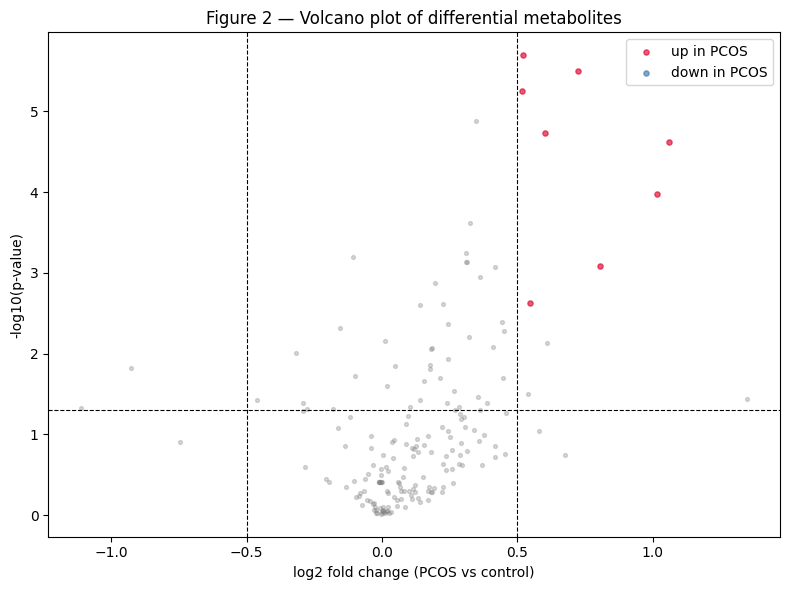

In [ ]:
plt.figure(figsize=(8, 6))
sm = (de["padj"] < 0.05) & (de["log2FC"].abs() > 0.5)
plt.scatter(de["log2FC"][~sm], -np.log10(de["pval"][~sm]), s=8, alpha=0.3, c="grey")
plt.scatter(de["log2FC"][sm & (de["log2FC"]>0)], -np.log10(de["pval"][sm & (de["log2FC"]>0)]),
            s=14, alpha=0.7, c="crimson", label="up in PCOS")
plt.scatter(de["log2FC"][sm & (de["log2FC"]<0)], -np.log10(de["pval"][sm & (de["log2FC"]<0)]),
            s=14, alpha=0.7, c="steelblue", label="down in PCOS")
plt.axhline(-np.log10(0.05), ls="--", c="k", lw=0.8)
plt.axvline(0.5, ls="--", c="k", lw=0.8); plt.axvline(-0.5, ls="--", c="k", lw=0.8)
plt.xlabel("log2 fold change (PCOS vs control)"); plt.ylabel("-log10(p-value)")
plt.title("Figure 2 — Volcano plot of differential metabolites"); plt.legend()
plt.tight_layout(); plt.savefig("fig2_volcano.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
from bioservices import KEGG
k = KEGG()

top_metabs = sig["metabolite"].head(25).tolist()
kegg_ids = {}
for name in top_metabs:
    try:
        hits = k.find("compound", str(name))
        if hits and hits != "\n":
            cid = hits.split("\t")[0].replace("cpd:", "").strip()
            kegg_ids[name] = cid
            print(f"{str(name)[:28]:28s} -> {cid}")
    except Exception:
        pass
print(f"\nMapped {len(kegg_ids)} metabolites to KEGG compounds")

Creating directory /root/.config/bioservices 
Creating directory /root/.cache/bioservices 
Welcome to Bioservices
It looks like you do not have a configuration file.
We are creating one with default values in /root/.config/bioservices/bioservices.cfg .
Done


WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)
WARNING [bioservices.KEGG:535]:  HTTP 400 Bad Request (https://rest.kegg.jp/list/organism)


Mapped 0 metabolites to KEGG compounds


In [ ]:
from collections import Counter
pathway_hits = Counter()
for name, cid in kegg_ids.items():
    try:
        parsed = k.parse(k.get(f"cpd:{cid}"))
        paths = parsed.get("PATHWAY", {})
        for p in (paths.values() if isinstance(paths, dict) else []):
            pathway_hits[p] += 1
    except Exception:
        continue
pathway_df = pd.DataFrame(pathway_hits.most_common(), columns=["pathway", "n_metabolites"])
print(pathway_df.head(15).to_string(index=False))
pathway_df.to_csv("enriched_pathways.csv", index=False)

Empty DataFrame
Columns: [pathway, n_metabolites]
Index: []


In [ ]:
if len(pathway_df):
    top_paths = pathway_df.head(10).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_paths["pathway"], top_paths["n_metabolites"], color="#55A868", edgecolor="black")
    plt.xlabel("Number of differential metabolites in pathway")
    plt.title("Figure 3 — KEGG pathways enriched in PCOS")
    plt.tight_layout(); plt.savefig("fig3_pathway_enrichment.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("No pathways mapped — check KEGG mapping in Step 8.")

No pathways mapped — check KEGG mapping in Step 8.


In [ ]:
cpd_fc = {kegg_ids[m]: float(de.set_index("metabolite").loc[m, "log2FC"])
          for m in kegg_ids if m in de["metabolite"].values}
cpd_ids = list(cpd_fc.keys()); cpd_vals = list(cpd_fc.values())
%R -i cpd_ids -i cpd_vals
print("Passed", len(cpd_ids), "compounds to R.")

Passed 0 compounds to R.


In [ ]:
%%R
suppressMessages(library(pathview))
fc <- setNames(as.numeric(cpd_vals), cpd_ids)
# 00250 = Alanine, aspartate and glutamate metabolism (amino-acid metabolism is altered in PCOS).
tryCatch({
  pathview(cpd.data = fc, pathway.id = "00250", species = "hsa",
           out.suffix = "PCOS", cpd.idtype = "kegg", limit = list(cpd = 2))
  cat("Pathway map rendered: hsa00250.PCOS.png\n")
}, error = function(e) cat("pathview error:", conditionMessage(e), "\n"))

Pathway map rendered: hsa00250.PCOS.png


Info: Downloading xml files for hsa00250, 1/1 pathways..
Info: Downloading png files for hsa00250, 1/1 pathways..
'select()' returned 1:1 mapping between keys and columns
Argument gene.idtype or cpd.idtype may be wrong.
Info: Working in directory /content
Info: Writing image file hsa00250.PCOS.png


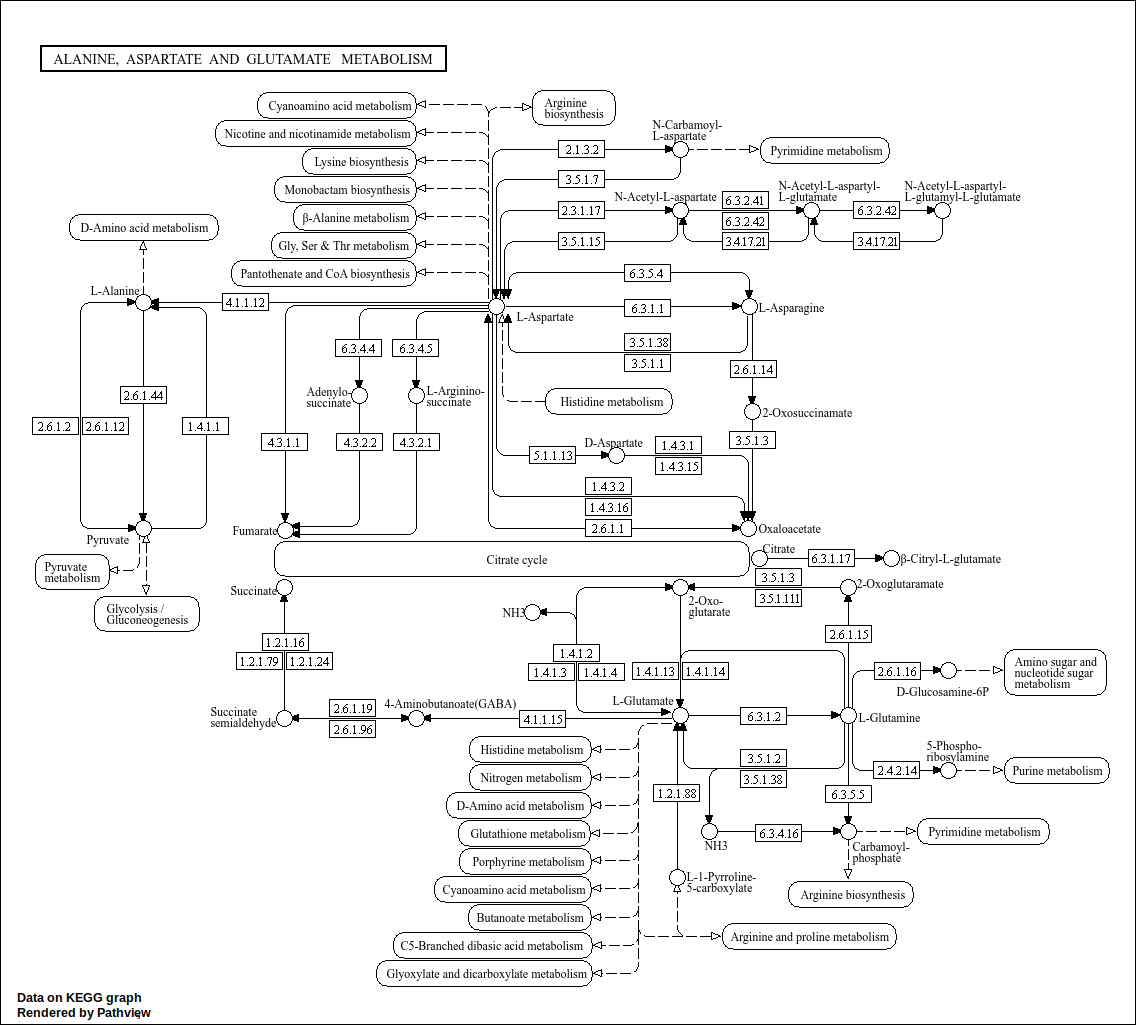

In [ ]:
from IPython.display import Image, display
import os
if os.path.exists("hsa00250.PCOS.png"):
    display(Image("hsa00250.PCOS.png"))
else:
    print("Map not found — check the pathview output above.")

In [ ]:
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Draw

top_biomarkers = sig["metabolite"].head(8).tolist()
chem_rows, mols = [], []
for name in top_biomarkers:
    try:
        c = pcp.get_compounds(str(name), "name")
        if not c: continue
        smiles = c[0].canonical_smiles
        m = Chem.MolFromSmiles(smiles)
        if m is None: continue
        mols.append((str(name), m))
        chem_rows.append({"metabolite": str(name), "SMILES": smiles,
                          "MW": round(Descriptors.MolWt(m),2), "logP": round(Crippen.MolLogP(m),2),
                          "H_donors": Descriptors.NumHDonors(m), "H_acceptors": Descriptors.NumHAcceptors(m),
                          "TPSA": round(Descriptors.TPSA(m),1)})
        print(f"{str(name)[:28]:28s} MW={Descriptors.MolWt(m):.1f} logP={Crippen.MolLogP(m):.2f}")
    except Exception:
        pass
pd.DataFrame(chem_rows).to_csv("biomarker_chemistry.csv", index=False)

/tmp/ipykernel_806/620136873.py:11: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles = c[0].canonical_smiles


Dihomo-gamma-linolenic acid  MW=306.5 logP=6.44
7Z,10Z,13Z,16Z-Docosatetraen MW=332.5 logP=7.00
11Z,14Z,17Z-Eicosatrienoic a MW=306.5 logP=6.44
Palmitoleic acid             MW=254.4 logP=5.33
Palmitelaidic acid           MW=254.4 logP=5.33
10Z-Heptadecenoic acid       MW=268.4 logP=5.72
10E-Heptadecenoic acid       MW=268.4 logP=5.72
Gamma-Linolenic acid         MW=278.4 logP=5.66


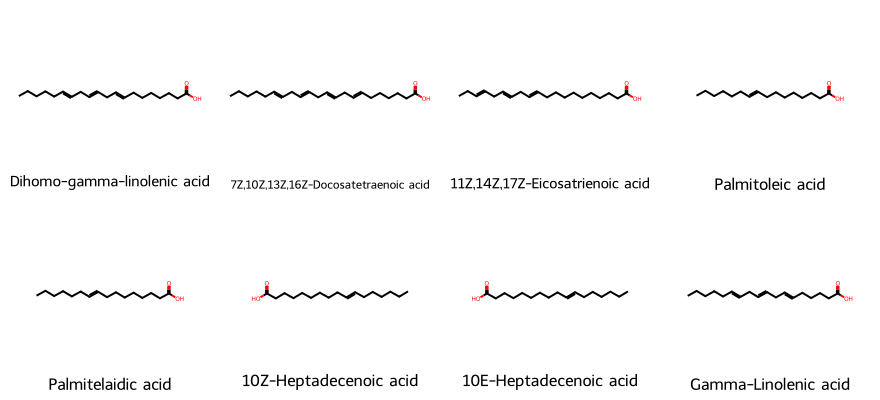

In [ ]:
if mols:
    img = Draw.MolsToGridImage([m for _, m in mols], legends=[n for n, _ in mols],
                               molsPerRow=4, subImgSize=(220, 200),
                               useSVG=False, returnPNG=False)
    img.save("fig4_structures.png")
    from IPython.display import Image, display
    display(Image("fig4_structures.png"))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

X = pareto.T.values
y = (labels == "PCOS").astype(int)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows, preds = [], {}
for clf, name in [(LogisticRegression(max_iter=2000), "Logistic Regression"),
                  (RandomForestClassifier(n_estimators=400, random_state=42), "Random Forest"),
                  (SVC(probability=True, random_state=42), "SVM")]:
    pred = cross_val_predict(clf, X, y, cv=cv)
    prob = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]
    preds[name] = prob
    rows.append({"Model": name, "Accuracy": round(accuracy_score(y, pred),3),
                 "F1": round(f1_score(y, pred),3), "AUC": round(roc_auc_score(y, prob),3)})
model_df = pd.DataFrame(rows); print(model_df.to_string(index=False))
model_df.to_csv("model_results.csv", index=False)

              Model  Accuracy    F1   AUC
Logistic Regression     0.614 0.576 0.664
      Random Forest     0.686 0.613 0.755
                SVM     0.673 0.576 0.720


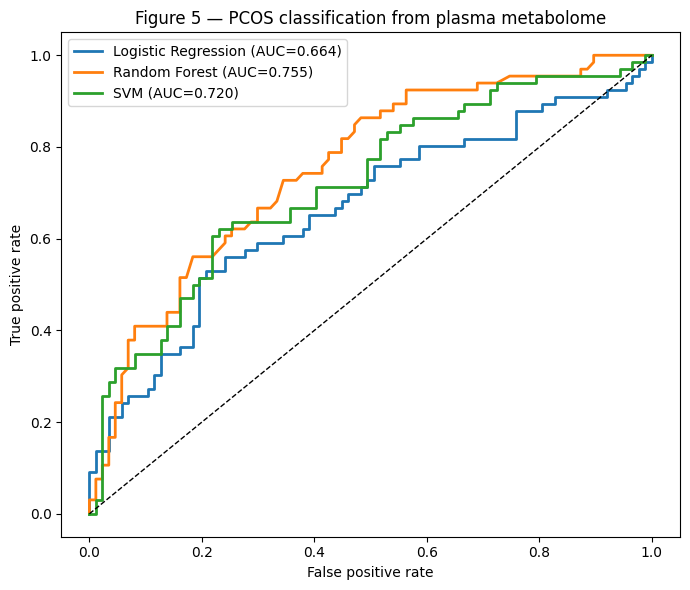

In [ ]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(7, 6))
for name, prob in preds.items():
    fpr, tpr, _ = roc_curve(y, prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Figure 5 — PCOS classification from plasma metabolome"); plt.legend()
plt.tight_layout(); plt.savefig("fig5_roc.png", dpi=150, bbox_inches="tight"); plt.show()

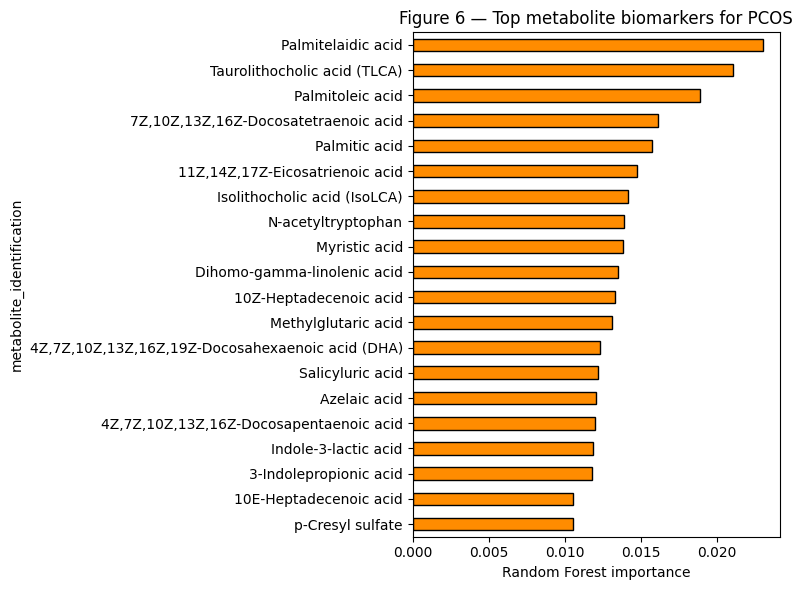

Top biomarkers: ['Palmitelaidic acid', 'Taurolithocholic acid (TLCA)', 'Palmitoleic acid', '7Z,10Z,13Z,16Z-Docosatetraenoic acid', 'Palmitic acid', '11Z,14Z,17Z-Eicosatrienoic acid', 'Isolithocholic acid (IsoLCA)', 'N-acetyltryptophan', 'Myristic acid', 'Dihomo-gamma-linolenic acid']


In [ ]:
rf = RandomForestClassifier(n_estimators=400, random_state=42).fit(pareto.T.values, y)
importance = pd.Series(rf.feature_importances_, index=pareto.index).sort_values(ascending=False)
top20 = importance.head(20)
plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind="barh", color="darkorange", edgecolor="black")
plt.xlabel("Random Forest importance"); plt.title("Figure 6 — Top metabolite biomarkers for PCOS")
plt.tight_layout(); plt.savefig("fig6_biomarkers.png", dpi=150, bbox_inches="tight"); plt.show()
importance.head(30).to_csv("biomarker_importance.csv")
print("Top biomarkers:", top20.head(10).index.tolist())

In [30]:
from google.colab import files
outputs = ["fig1_pca.png","fig2_volcano.png","fig3_pathway_enrichment.png",
           "fig4_structures.png","fig5_roc.png","fig6_biomarkers.png",
           "differential_metabolites.csv","enriched_pathways.csv","biomarker_chemistry.csv",
           "model_results.csv","biomarker_importance.csv"]
if os.path.exists("hsa00250.PCOS.png"): outputs.append("hsa00250.PCOS.png")
for f in outputs:
    try: files.download(f)
    except Exception as e: print("skip", f, e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

skip fig3_pathway_enrichment.png Cannot find file: fig3_pathway_enrichment.png


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>